[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lijingwang/UConn_MODFLOW_Lab/blob/main/UConn_Forest/03_Model_Input_Data_Prep.ipynb)

# Watershed Input Data Collection

Author: Lijing Wang (lijing.wang@uconn.edu) for ERTH 4750 at University of Connecticut

Automatically downloads all spatial inputs needed for a groundwater model given a watershed shapefile.

**Inputs collected:**
1. **DEM** — USGS 3DEP seamless (1 / 3 / 10 / 30 m options)
2. **Hydrography** — NHDPlus V2 / NHDPlus HR (selectable)
3. **Soil layer (Layer 1)** — SSURGO: K, porosity, Sy, depth
4. **Regolith layer (Layer 2)** — GLHYMPS: K, porosity
5. **Depth to bedrock** — SoilGrids BDTICM: Layer 1 + Layer 2 thicknesses

**Change only the config cell to use your own watershed.**

In [1]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_DIR = '/content/drive/MyDrive/MODFLOW_Lab'
    if not os.path.exists(os.path.join(REPO_DIR, 'UConn_Forest')):
        print('Cloning UConn_MODFLOW_Lab into Drive ...')
        subprocess.run(['git', 'clone',
                        'https://github.com/lijingwang/UConn_MODFLOW_Lab',
                        REPO_DIR], check=True)
        print('Clone complete.')

    DRIVE_DIR = os.path.join(REPO_DIR, 'UConn_Forest')
    os.chdir(DRIVE_DIR)
    print('Working directory →', os.getcwd())
else:
    print('Local: working directory →', os.getcwd())

Local: working directory → /mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/MODFLOW/UConn_MODFLOW_fenton/Fenton


In [2]:
! pip install py3dep pynhd pygeoogc rasterio rioxarray geopandas requests matplotlib -q

# ── Manual uploads required (one-time) ─────────────────────────────────────
# Upload these to /content/drive/MyDrive/MODFLOW_Lab/Real_case_study/ :
#   UConn_forest.shp (+ .dbf .prj .shx)     — watershed boundary
#   GLHYMPS/GLHYMPS.shp (+ supporting files) — download: https://doi.org/10.5683/SP2/TTJNIU
#   SoilGrids/BDTICM_M_250m_ll.tif            — download: http://globalchange.bnu.edu.cn/research/dtb.jsp

import warnings
warnings.filterwarnings('ignore')
print('Packages loaded.')
%config InlineBackend.figure_format='retina'

Packages loaded.


## 1. Configuration — change only this cell

In [3]:
import os

# ── Change only this block ──────────────────────────────────────
SHAPEFILE  = 'model_inputs/Watershed_Fenton.shp'   # watershed boundary shapefile, in WGS84! 
OUTPUT_DIR = 'model_inputs'        # output folder
DEM_RES    = 50 # DEM resolution [metres]
# CRS is auto-detected from shapefile location (best UTM zone in metres)
# ────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Shapefile  : {SHAPEFILE}')
print(f'Output dir : {OUTPUT_DIR}/')

Shapefile  : model_inputs/Watershed_Fenton.shp
Output dir : model_inputs/


## 2. Load Watershed Boundary

Input CRS        : EPSG:26919
Auto UTM CRS     : EPSG:32618
Bounds (lon/lat) : [-72.2851  41.7757 -72.1788  41.9626]
Area             : 82.90 km²


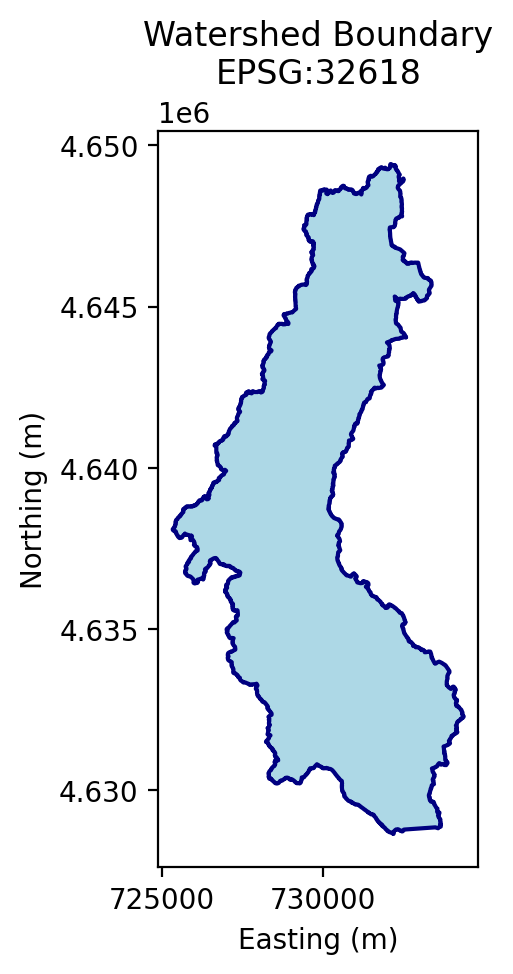

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

ws = gpd.read_file(SHAPEFILE)

# Step 1 — ensure WGS84 for web queries
ws_wgs84 = ws.to_crs('EPSG:4326')

# Step 2 — auto-detect best UTM zone (metres) for this location
CRS_OUT = ws_wgs84.estimate_utm_crs()
ws_proj = ws_wgs84.to_crs(CRS_OUT)

geom_wgs84 = ws_wgs84.geometry.union_all()
bounds     = ws_wgs84.total_bounds   # (minx, miny, maxx, maxy) lon/lat

print(f'Input CRS        : {ws.crs}')
print(f'Auto UTM CRS     : {CRS_OUT}')
print(f'Bounds (lon/lat) : {bounds.round(4)}')
print(f'Area             : {ws_proj.geometry.area.sum()/1e6:.2f} km²')

fig, ax = plt.subplots(figsize=(5, 5))
ws_proj.plot(ax=ax, facecolor='lightblue', edgecolor='navy', lw=1.5)
ax.set_title(f'Watershed Boundary\n{CRS_OUT}')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
plt.tight_layout(); plt.show()

## 3. DEM — USGS 3DEP Seamless

**Source:** USGS 3D Elevation Program (3DEP) — Seamless DEM, served via the [TNM (The National Map)](https://www.usgs.gov/3d-elevation-program).  
`py3dep.get_dem()` queries the 3DEP WCS endpoint and returns an `xarray.DataArray` in **WGS84 (EPSG:4326)**, which is then reprojected to the auto-detected UTM CRS for saving and plotting.

**Set `DEM_RES` in the config cell to choose resolution:**

| `DEM_RES` | Product | Notes |
|---|---|---|
| `1` | 1 m (LIDAR-derived) | Highest detail; available only where LIDAR campaigns exist (many urban/suburban areas) |
| `3` | 3 m (1/9 arc-sec) | Limited CONUS coverage |
| `10` | 10 m (1/3 arc-sec) | Standard CONUS product |
| `30` | 30 m (1 arc-sec) | Fastest download; always available; good for large basins |

> If the requested resolution is not available for your area, py3dep falls back to the nearest coarser product automatically.

Saved: model_inputs/dem_50m.tif
Elevation range : 64.6 – 364.0 m
Shape           : (517, 338)


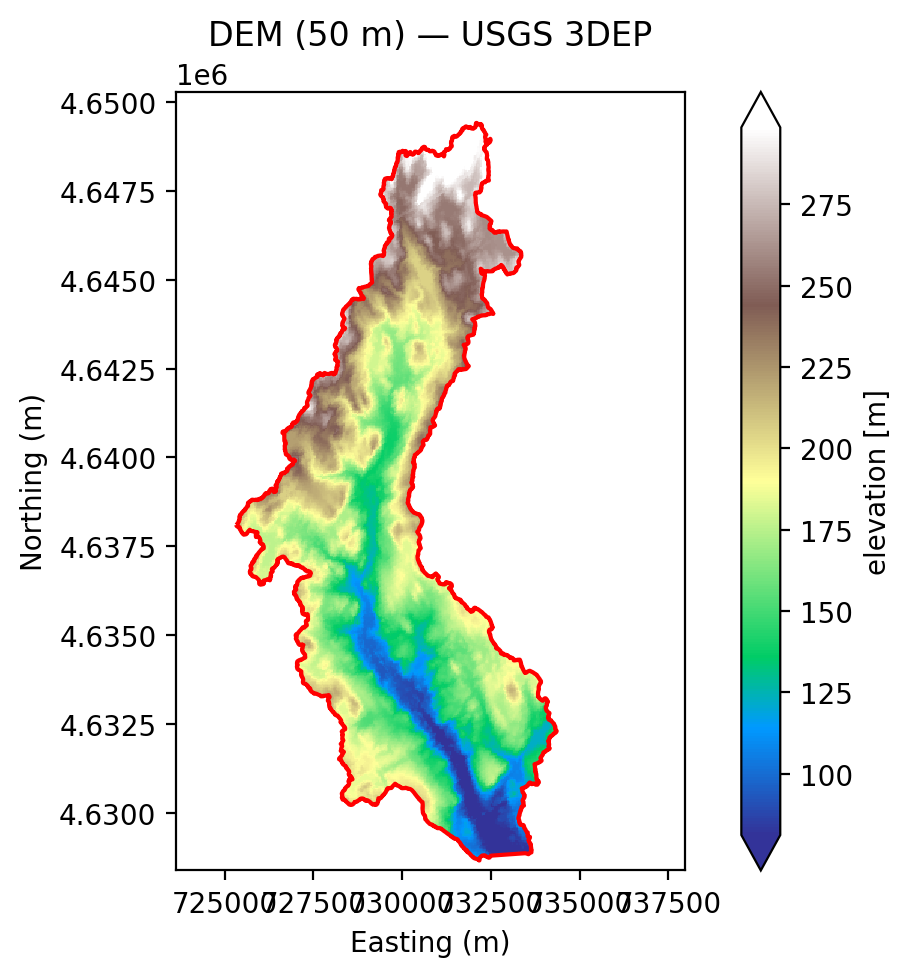

In [5]:
import py3dep
import numpy as np

print(f'Downloading {DEM_RES} m DEM from USGS 3DEP ...')
dem = py3dep.get_dem(geom_wgs84, resolution=DEM_RES)

# Reproject to UTM — save and plot in same CRS as watershed boundary
dem_proj = dem.rio.reproject(CRS_OUT)
dem_path = f'{OUTPUT_DIR}/dem_{DEM_RES}m.tif'
dem_proj.rio.to_raster(dem_path)
print(f'Saved: {dem_path}')

dem_arr = dem_proj.values
print(f'Elevation range : {np.nanmin(dem_arr):.1f} – {np.nanmax(dem_arr):.1f} m')
print(f'Shape           : {dem_arr.shape}')

# Both dem_proj and ws_proj are in UTM → same CRS, square pixels, correct overlay
fig, ax = plt.subplots(figsize=(6, 5))
dem_proj.plot(ax=ax, cmap='terrain', robust=True)
ws_proj.boundary.plot(ax=ax, color='red', lw=1.5)
ax.set_title(f'DEM ({DEM_RES} m) — USGS 3DEP')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
plt.tight_layout(); plt.show()

## 4. Hydrography — Stream Network

Two NHD products are available via pynhd. Set `NHD_PRODUCT` in the code cell below:

| `NHD_PRODUCT` | Product | Scale | Routing | Best for |
|---|---|---|---|---|
| `'nhdplus_v2'` | NHDPlus V2 | 1:100,000 | Yes (COMID, Hydroseq, catchments) | Regional / national analysis |
| `'nhdplus_hr'` | **NHDPlus HR** | **1:24,000** | Yes | **Small watersheds (< ~200 km²) — recommended** |

**Key differences:**
- **NHDPlus V2** — 1:100,000 scale with full routing attributes (flow direction, upstream area, mean annual flow). Headwater streams (1st–2nd order) are often absent for small basins.
- **NHDPlus HR** — 1:24,000 scale; captures small headwater streams that V2 misses. Best choice for watersheds < 200 km². Also the product used by sfrmaker for SFR package construction.

> Basic NHD (geometry-only, no routing) is not exposed as a separate layer in pynhd's `WaterData`.

Saved  : model_inputs/streams_nhd.shp
Reaches: 15
Stream orders: [np.int64(1), np.int64(2)]


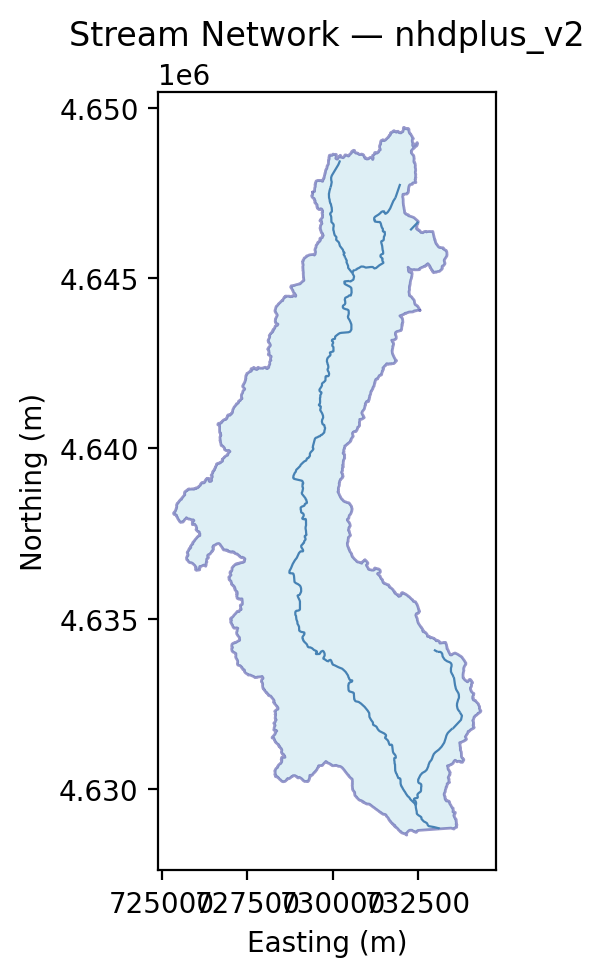

In [6]:
from pynhd import WaterData, NHDPlusHR

# ── Choose NHD product ─────────────────────────────────────────────
#   'nhdplus_v2'  — NHDPlus V2 (1:100,000) + routing attributes
#   'nhdplus_hr'  — NHDPlus HR (1:24,000), best for small watersheds
NHD_PRODUCT = 'nhdplus_v2'
# ──────────────────────────────────────────────────────────────────

print(f'Downloading flowlines [{NHD_PRODUCT}] ...')
if NHD_PRODUCT == 'nhdplus_v2':
    streams = WaterData('nhdflowline_network').bygeom(geom_wgs84)
elif NHD_PRODUCT == 'nhdplus_hr':
    streams = NHDPlusHR('flowline').bygeom(geom_wgs84)
else:
    raise ValueError(f'Unknown NHD_PRODUCT: {NHD_PRODUCT!r}. '
                     'Choose nhdplus_v2 or nhdplus_hr.')

if len(streams) == 0:
    print('No streams found — try a different NHD_PRODUCT or check watershed bounds.')
else:
    # Reproject → clip to watershed boundary
    streams_proj = gpd.clip(streams.to_crs(CRS_OUT), ws_proj)
    shp_path = f'{OUTPUT_DIR}/streams_nhd.shp'
    streams_proj.to_file(shp_path)
    print(f'Saved  : {shp_path}')
    print(f'Reaches: {len(streams_proj)}')

    # Stream order column name differs by product
    for order_col in ['streamorde', 'StreamOrder', 'streamorder', 'strmord']:
        if order_col in streams_proj.columns:
            print(f'Stream orders: {sorted(streams_proj[order_col].dropna().unique())}')
            break

    fig, ax = plt.subplots(figsize=(6, 5))
    ws_proj.plot(ax=ax, facecolor='lightblue', edgecolor='navy', lw=1, alpha=0.4)
    streams_proj.plot(ax=ax, color='steelblue', lw=0.8)
    ax.set_title(f'Stream Network — {NHD_PRODUCT}')
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    plt.tight_layout(); plt.show()

## 5. Soils — SSURGO (Ksat, Sy, Porosity, Depth)

**SSURGO** (Soil Survey Geographic Database) queried through the **SDA (Soil Data Access)** REST API at `sdmdataaccess.sc.egov.usda.gov/tabular/post.rest`.  

| SSURGO column | Physical meaning | MODFLOW parameter | Conversion |
|---|---|---|---|
| `ksat_r` [µm/s] | Saturated hydraulic conductivity | **K** | × 1×10⁻⁶ → m/s |
| `wsatiated_r` [%] | θ_s = saturated VWC = total porosity | total porosity | ÷ 100 |
| `wthirdbar_r` [%] | θ_fc = field capacity VWC | (used to compute Sy) | ÷ 100 |
| **Sy = θ_s − θ_fc** | Drainable porosity (gravity-drained water) | **Sy** | `(wsatiated_r − wthirdbar_r) / 100` |
| `MAX(hzdepb_r)` [cm] | Deepest horizon bottom = soil profile depth | **Thickness** | ÷ 100 → m |

> **Why Sy ≠ porosity:** `wsatiated_r` (θ_s) is the *total* pore space. But pores at field capacity (θ_fc) retain water against gravity and do not drain. Only the gravity-drainable fraction θ_s − θ_fc contributes to Sy in MODFLOW. 

**Layer thickness sources:**
- **Layer 1 (regolith):** `MAX(hzdepb_r)` gives mapped soil profile depth (typically 1–2 m in SSURGO). 


Querying SSURGO SDA ...
  Map units: 78
                                                                         muname     ksat_m_s  porosity      Sy  soil_depth_m
                                                          Occum fine sandy loam 8.000000e-06    0.3680 0.23040          1.65
                                                      Pootatuck fine sandy loam 1.840000e-05    0.3680 0.24240          1.65
                                                       Rippowam fine sandy loam 8.000000e-06    0.3680 0.22880          1.65
   Saco silt loam, frequently ponded, 0 to 2 percent slopes, frequently flooded 7.380000e-06    0.3936 0.15416          1.52
                            Fluvaquents-Udifluvents complex, frequently flooded 2.970000e-05    0.3910 0.19460          1.52
                                        Raypol silt loam, 0 to 3 percent slopes 4.400000e-06    0.4000 0.21200          1.65
                                      Walpole sandy loam, 0 to 3 percent slopes 7.999

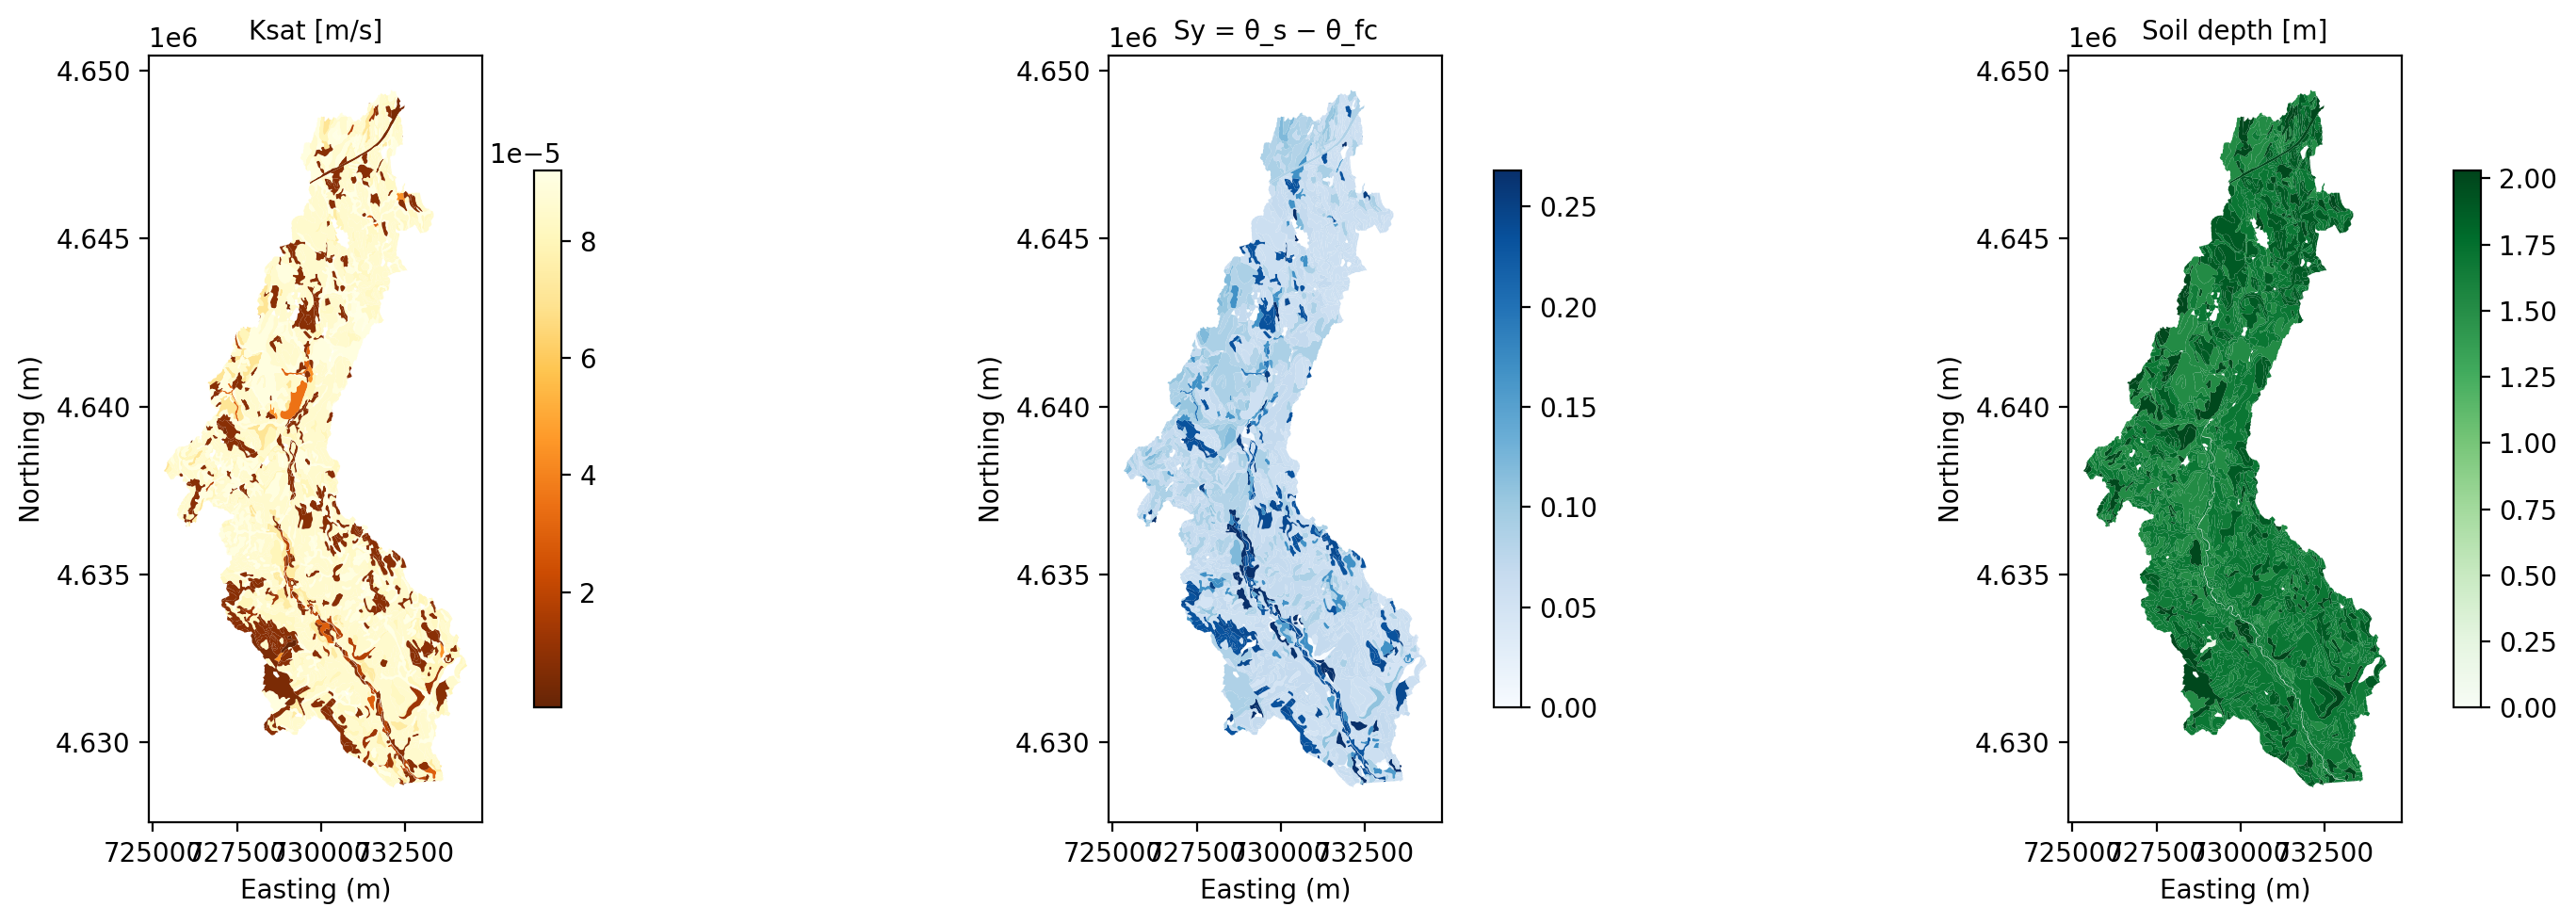

  Ksat      : 4.48e-05 m/s
  Porosity  : 0.390  (total, θ_s)
  Sy        : 0.137  (drainable = θ_s − θ_fc)
  Depth     : 1.66 m  → Layer 1 thickness
  Ss        : ~1e-4 m⁻¹  (regolith, literature)


In [7]:
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.wkt import loads as wkt_loads
import rasterio
from rasterio.features import rasterize as rio_rasterize
from rasterio.transform import from_bounds
import rioxarray as rxr

SDA_URL = 'https://sdmdataaccess.sc.egov.usda.gov/tabular/post.rest'

def sda_query(sql):
    r = requests.post(SDA_URL, data={'query': sql, 'format': 'JSON+COLUMNNAME'}, timeout=90)
    r.raise_for_status()
    j = r.json()
    if 'Table' not in j or len(j['Table']) < 2:
        return pd.DataFrame()
    return pd.DataFrame(j['Table'][1:], columns=j['Table'][0])

minx, miny, maxx, maxy = bounds
aoi_wkt = (f'POLYGON(({minx} {miny},{maxx} {miny},'
           f'{maxx} {maxy},{minx} {maxy},{minx} {miny}))')

# ── 1. Tabular ────────────────────────────────────────────────────
print('Querying SSURGO SDA ...')
sql_tab = f"""
SELECT mu.mukey, mu.muname,
  SUM(CASE WHEN h.hzdept_r = 0
        THEN CAST(h.ksat_r       AS FLOAT) * c.comppct_r / 100.0 ELSE 0 END) AS ksat_um_s,
  SUM(CASE WHEN h.hzdept_r = 0
        THEN CAST(h.wsatiated_r  AS FLOAT) * c.comppct_r / 100.0 ELSE 0 END) AS theta_s_pct,
  SUM(CASE WHEN h.hzdept_r = 0
        THEN CAST(h.wthirdbar_r  AS FLOAT) * c.comppct_r / 100.0 ELSE 0 END) AS theta_fc_pct,
  MAX(CAST(h.hzdepb_r AS FLOAT)) AS soil_depth_cm
FROM mapunit mu
INNER JOIN component c ON mu.mukey = c.mukey AND c.majcompflag = 'Yes'
INNER JOIN chorizon h   ON c.cokey  = h.cokey
WHERE mu.mukey IN (
  SELECT * FROM SDA_Get_Mukey_from_intersection_with_WktWgs84('{aoi_wkt}')
)
GROUP BY mu.mukey, mu.muname ORDER BY mu.mukey
"""
tab = sda_query(sql_tab)
for col in ['ksat_um_s', 'theta_s_pct', 'theta_fc_pct', 'soil_depth_cm']:
    tab[col] = pd.to_numeric(tab[col], errors='coerce')

# Unit conversions
tab['ksat_m_s']     = tab['ksat_um_s']   * 1e-6    # µm/s → m/s
tab['porosity']     = tab['theta_s_pct'] / 100.0   # θ_s [%] → total porosity [0–1]
# Sy = drainable porosity = θ_s − θ_fc  (water that drains by gravity)
# θ_fc = field capacity (water held against gravity; does NOT drain → not part of Sy)
tab['Sy']           = ((tab['theta_s_pct'] - tab['theta_fc_pct']) / 100.0).clip(lower=0)
tab['soil_depth_m'] = tab['soil_depth_cm'] / 100.0  # cm → m

print(f'  Map units: {len(tab)}')
print(tab[['muname', 'ksat_m_s', 'porosity', 'Sy', 'soil_depth_m']].to_string(index=False))
tab.to_csv(f'{OUTPUT_DIR}/soil_ssurgo_table.csv', index=False)
print(f'  Saved: {OUTPUT_DIR}/soil_ssurgo_table.csv')

# ── 2. Spatial polygons (inline geometry) ─────────────────────────
print('\nQuerying SSURGO spatial polygons ...')
sql_spatial = f"""
SELECT mukey, musym,
  mupolygongeo.STIntersection(
    geometry::STGeomFromText('{aoi_wkt}', 4326).MakeValid()
  ).STAsText() AS wktgeom
FROM mupolygon
WHERE mupolygongeo.STIntersects(
  geometry::STGeomFromText('{aoi_wkt}', 4326).MakeValid()) = 1
"""
geo_df = sda_query(sql_spatial)
geo_df['geometry'] = geo_df['wktgeom'].apply(wkt_loads)
gdf = gpd.GeoDataFrame(geo_df.drop(columns='wktgeom'),
                        geometry='geometry', crs='EPSG:4326')
print(f'  Polygons: {len(gdf)}')

# ── 3. Merge → UTM → clip → save ─────────────────────────────────
soil_vec = gdf.merge(tab, on='mukey', how='left').to_crs(CRS_OUT)
soil_vec = gpd.clip(soil_vec, ws_proj)
soil_vec.to_file(f'{OUTPUT_DIR}/soil_ssurgo.shp')
print(f'  Saved: {OUTPUT_DIR}/soil_ssurgo.shp  ({len(soil_vec)} polygons)')

# ── 4. Rasterize to DEM grid ─────────────────────────────────────
dem_r      = rxr.open_rasterio(f'{OUTPUT_DIR}/dem_{DEM_RES}m.tif', masked=True).squeeze()
h_px, w_px = dem_r.shape
tf         = from_bounds(*dem_r.rio.bounds(), width=w_px, height=h_px)
crs_rio    = dem_r.rio.crs

for col, fname, label in [
    ('ksat_m_s',     'soil_ksat.tif',    'Ksat [m/s]'),
    ('porosity',     'soil_porosity.tif','Total porosity [–]'),
    ('Sy',           'soil_Sy.tif',      'Sy [–]'),
    ('soil_depth_m', 'soil_depth_m.tif', 'Soil depth [m]'),
]:
    vals   = pd.to_numeric(soil_vec[col], errors='coerce').fillna(0).values.astype('float32')
    shapes = [(g, v) for g, v in zip(soil_vec.geometry, vals) if v > 0]
    arr    = rio_rasterize(shapes, out_shape=(h_px, w_px), transform=tf,
                           fill=np.nan, dtype='float32')
    out_path = f'{OUTPUT_DIR}/{fname}'
    with rasterio.open(out_path, 'w', driver='GTiff', height=h_px, width=w_px,
                       count=1, dtype='float32', crs=crs_rio,
                       transform=tf, nodata=np.nan) as dst:
        dst.write(arr, 1)
    print(f'  {label:<22} → {fname}  range {np.nanmin(arr):.3e} – {np.nanmax(arr):.3e}')

# ── 5. Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title, cmap in zip(
        axes,
        ['ksat_m_s', 'Sy', 'soil_depth_m'],
        ['Ksat [m/s]',
         'Sy = θ_s − θ_fc',
         'Soil depth [m]'],
        ['YlOrBr_r', 'Blues', 'Greens']):
    soil_vec.plot(column=col, ax=ax, cmap=cmap, legend=True,
                  legend_kwds={'shrink': 0.7})
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
plt.tight_layout(); plt.show()

print(f'  Ksat      : {tab["ksat_m_s"].mean():.2e} m/s')
print(f'  Porosity  : {tab["porosity"].mean():.3f}  (total, θ_s)')
print(f'  Sy        : {tab["Sy"].mean():.3f}  (drainable = θ_s − θ_fc)')
print(f'  Depth     : {tab["soil_depth_m"].mean():.2f} m  → Layer 1 thickness')
print(f'  Ss        : ~1e-4 m⁻¹  (regolith, literature)')

## 6. Regolith Layer — GLHYMPS 2.0 (K and Porosity)

**GLHYMPS 2.0** (Gleeson et al. 2014; Huscroft et al. 2018) maps geological formations worldwide — unconsolidated deposits and bedrock — providing hydraulic conductivity and porosity. Here we use it for the **regolith layer** (unconsolidated material between the soil profile and fresh bedrock).

**Download (one-time, manual):**  
→ `https://doi.org/10.5683/SP2/TTJNIU` (Scholars Portal Dataverse, ~200 MB)  
→ Unzip and place `GLHYMPS.shp` (+ `.dbf`, `.shx`, `.prj`) in a local folder.  
→ Set `GLHYMPS_PATH` in the cell below.

| GLHYMPS column | Meaning | MODFLOW use |
|---|---|---|
| `logK_Ferr_` | log₁₀(k) × 100 [m²] | → K Layer 2 (regolith) |
| `Porosity_x` | porosity × 100 [%] | → porosity Layer 2 |

**K [m/s] = 10^(logK_Ferr_ / 100) × 9.81×10⁶**  (permeability [m²] → hydraulic conductivity [m/s] at 20 °C)

GLHYMPS CRS   : PROJCS["Cylindrical_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Cylindrical_Equal_Area"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Watershed CRS : EPSG:4326
Polygons in bbox: 2
Polygons in watershed: 2
Saved: model_inputs/regolith_glhymps.shp

Regolith layer (Layer 2) from GLHYMPS:
  logK_Ferr_ raw    : -1052 – -1052  (stored ×100)
  log10(k)          : -10.52 – -10.52  [m²]
  K range           : 2.96e-04 – 2.96e-04 m/s
  Porosity range    : 0.300 – 0.300


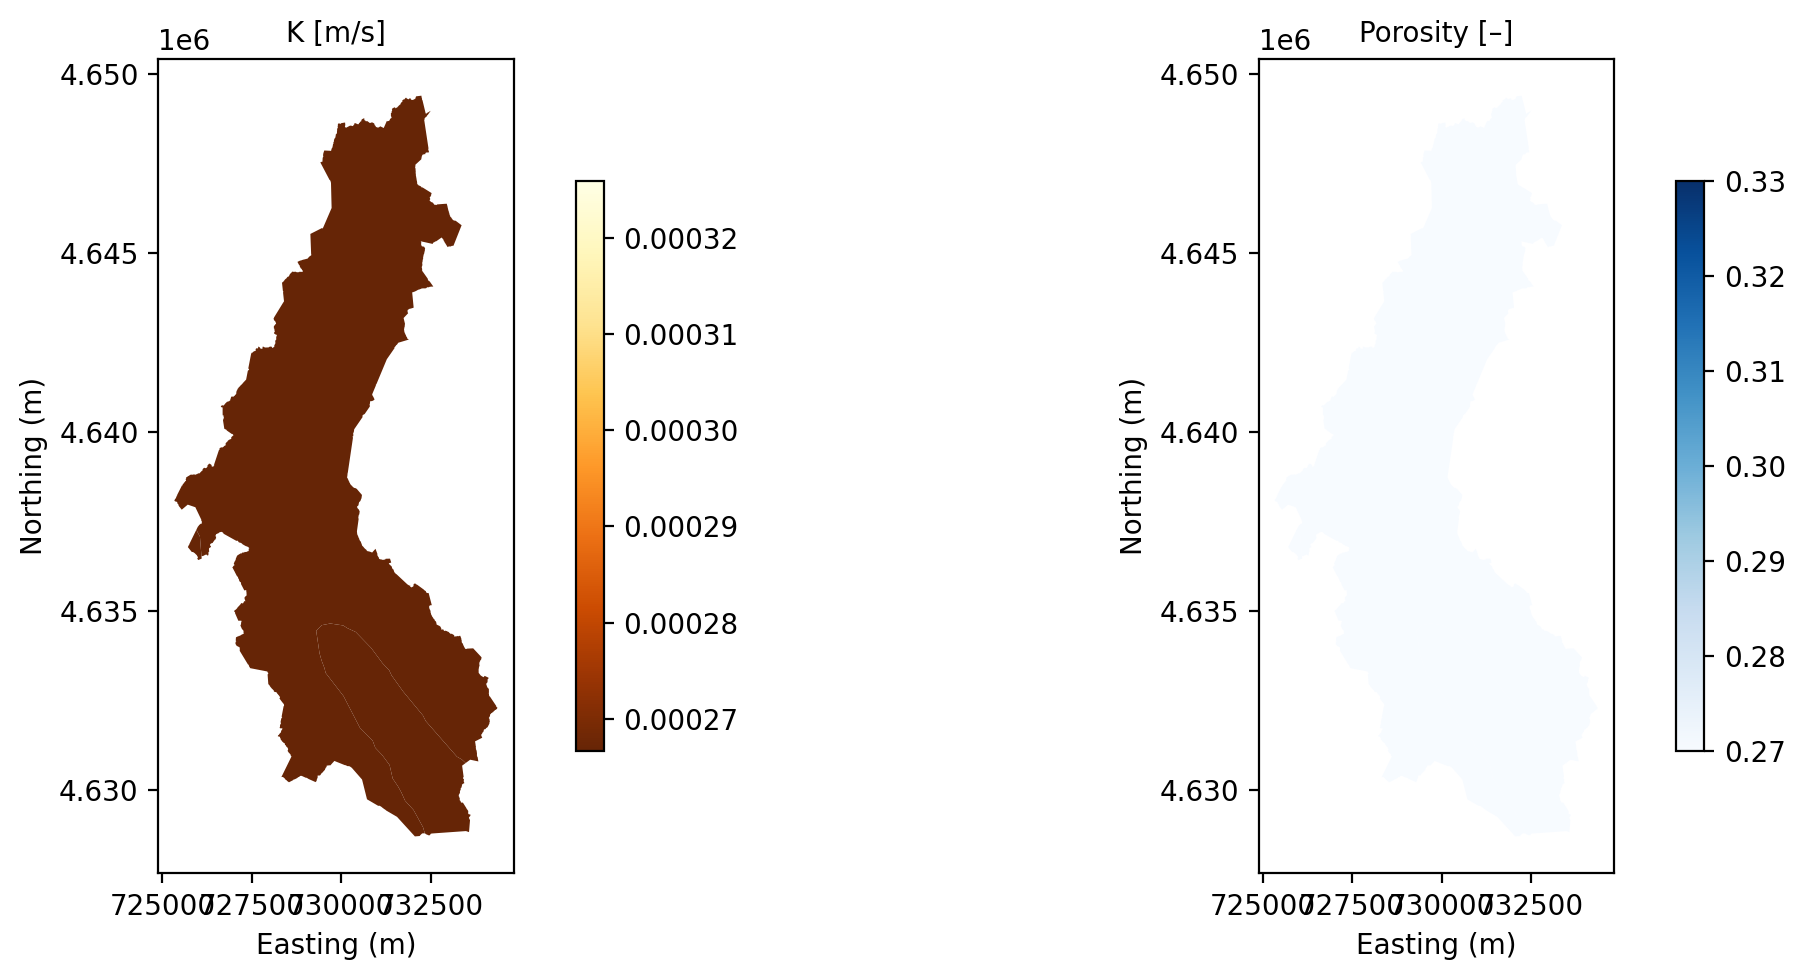

In [8]:
import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

GLHYMPS_PATH = 'model_inputs/GLHYMPS_fenton.shp'   # ← change if placed elsewhere

if not os.path.exists(GLHYMPS_PATH):
    print(f'GLHYMPS not found at: {GLHYMPS_PATH}')
    print('  1. Download from https://doi.org/10.5683/SP2/TTJNIU')
    print('  2. Unzip and place GLHYMPS.shp in working directory')
    print('  3. Update GLHYMPS_PATH above and re-run this cell')
else:
    # Check native CRS — always reproject bounds into GLHYMPS CRS for bbox filter
    glhymps_crs = gpd.read_file(GLHYMPS_PATH, rows=1).crs
    print(f'GLHYMPS CRS   : {glhymps_crs}')
    print(f'Watershed CRS : {ws_wgs84.crs}')

    ws_in_glhymps_crs = ws_wgs84.to_crs(glhymps_crs)
    bbox = tuple(ws_in_glhymps_crs.total_bounds)

    glhymps = gpd.read_file(GLHYMPS_PATH, bbox=bbox)
    print(f'Polygons in bbox: {len(glhymps)}')

    if len(glhymps) == 0:
        print('WARNING: No GLHYMPS polygons found — check shapefile is complete.')
    else:
        geo_clip = gpd.clip(glhymps.to_crs(CRS_OUT), ws_proj).copy()
        print(f'Polygons in watershed: {len(geo_clip)}')

        # logK_Ferr_ is stored as log10(k [m²]) × 100  (integer storage convention)
        # e.g. -1052 → log10(k) = -10.52 → k = 3e-11 m² → K ≈ 3e-4 m/s
        geo_clip['logK_m2']  = geo_clip['logK_Ferr_'] / 100.0
        geo_clip['K_m_s']    = 10 ** geo_clip['logK_m2'] * 9.81e6
        #geo_clip['porosity'] = geo_clip['Porosity_x'] / 100.0
        geo_clip['porosity'] = 0.3
        
        geo_clip.to_file(f'{OUTPUT_DIR}/regolith_glhymps.shp')
        print(f'Saved: {OUTPUT_DIR}/regolith_glhymps.shp')

        print(f'\nRegolith layer (Layer 2) from GLHYMPS:')
        print(f'  logK_Ferr_ raw    : {geo_clip["logK_Ferr_"].min():.0f} – {geo_clip["logK_Ferr_"].max():.0f}  (stored ×100)')
        print(f'  log10(k)          : {geo_clip["logK_m2"].min():.2f} – {geo_clip["logK_m2"].max():.2f}  [m²]')
        print(f'  K range           : {geo_clip["K_m_s"].min():.2e} – {geo_clip["K_m_s"].max():.2e} m/s')
        print(f'  Porosity range    : {geo_clip["porosity"].min():.3f} – {geo_clip["porosity"].max():.3f}')

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, col, title, cmap in zip(
                axes,
                ['K_m_s', 'porosity'],
                ['K [m/s]',
                 'Porosity [–]'],
                ['YlOrBr_r', 'Blues']):
            geo_clip.plot(column=col, ax=ax, cmap=cmap, legend=True,
                          legend_kwds={'shrink': 0.7})
            ax.set_title(title, fontsize=10)
            ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
        plt.tight_layout(); plt.show()

## 7. Depth to Bedrock — SoilGrids BDTICM (250 m)

**BDTICM** (Absolute Depth to Bedrock, Thomsen method) gives the vertical distance from the surface to unweathered bedrock in cm. It defines:

- **Bottom of Layer 1 (soil)** = SSURGO `MAX(hzdepb_r)` ← from Section 5
- **Bottom of Layer 2 (regolith)** = BDTICM depth to bedrock
- **Layer 2 thickness** = depth to bedrock − soil depth

**Download (one-time, manual):**  
→ `http://globalchange.bnu.edu.cn/research/dtb.jsp`  
→ Place the TIF in your working directory and set `BDTICM_PATH` below.

| Variable | Resolution | Unit |
|---|---|---|
| `BDTICM_M_250m_ll` | **250 m** | cm (÷ 100 → m) |

Reading model_inputs/SoilGrids/BDTICM_M_250m_ll.tif (clipping to watershed bbox before loading) ...
  Clipped bbox shape (WGS84): (187, 148)
  Reprojected shape (UTM)   : (209, 128)
Saved: depth_to_bedrock_m.tif
  Depth to bedrock: 4.8 – 27.2 m

Layer thickness estimates (watershed mean):
  Layer 1 (soil)     : 1.66 m   ← SSURGO hzdepb_r
  Layer 2 (regolith) : 10.6 m   ← BDTICM − soil depth
  Total to bedrock   : 12.3 m   ← BDTICM


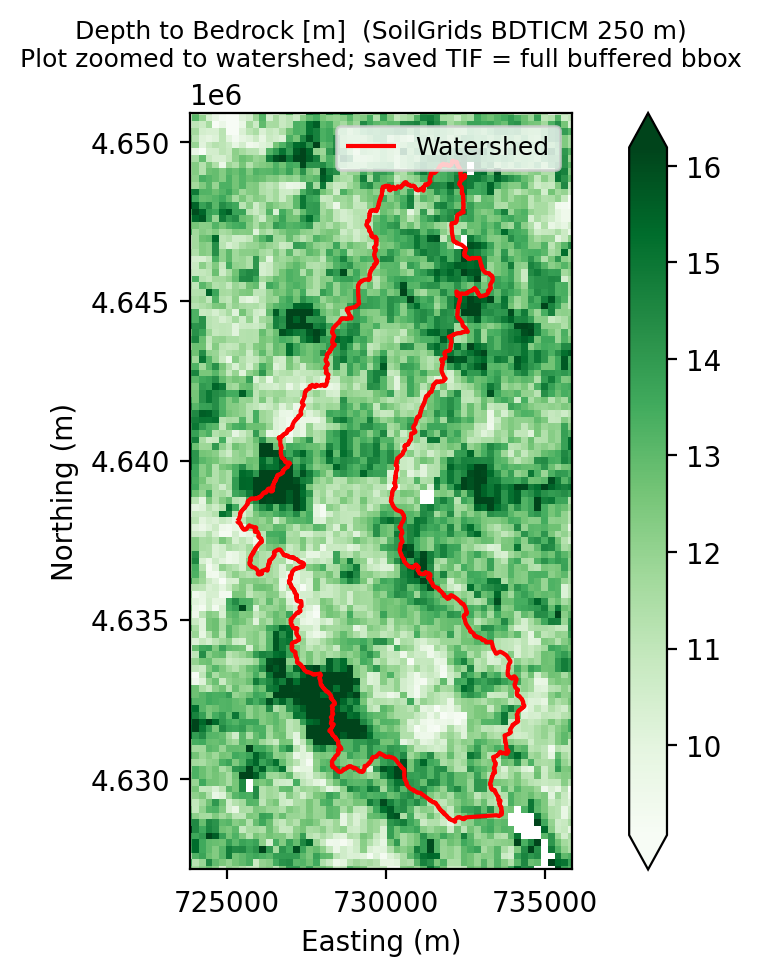

In [9]:
import rasterio
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt

# ── Set path to local BDTICM file ─────────────────────────────────────
# Download from http://globalchange.bnu.edu.cn/research/dtb.jsp
BDTICM_PATH = 'model_inputs/SoilGrids/BDTICM_M_250m_ll.tif'  

if not os.path.exists(BDTICM_PATH):
    print(f'BDTICM file not found at: {BDTICM_PATH}')
    print('  Download from http://globalchange.bnu.edu.cn/research/dtb.jsp')
    print('  Then update BDTICM_PATH above and re-run.')
else:
    print(f'Reading {BDTICM_PATH} (clipping to watershed bbox before loading) ...')
    depth_rx = rxr.open_rasterio(BDTICM_PATH, masked=True).squeeze()

    # ── Why clip_box before reproject? ────────────────────────────────
    # BDTICM is a global raster (~7.9 GB, 67200×172800 px). Loading the
    # entire file into memory would crash the kernel. clip_box() uses lazy
    # index arithmetic to read only the small window corresponding to the
    # watershed bounding box — the actual pixel data for the rest of the
    # globe is never fetched from disk.
    #
    # Why NO polygon clip afterward?
    # BDTICM is at 250 m resolution; the watershed is ~5 km across. A strict
    # polygon clip would discard cells whose *centre* falls just outside the
    # boundary, leaving large NaN holes along the watershed edge. Instead we
    # save the full buffered bounding box. Notebook 05 upsamples this raster
    # to the 10 m model grid, so the extra border pixels cause no harm —
    # inactive model cells (outside the watershed) are masked by idomain = 0.
    minx, miny, maxx, maxy = bounds   # WGS84 lon/lat bounds from Section 2
    buf = 0.1   # 0.1° buffer (~11 km) — generous to avoid edge drop-out
    depth_rx = depth_rx.rio.clip_box(
        minx=minx - buf, miny=miny - buf,
        maxx=maxx + buf, maxy=maxy + buf
    )
    print(f'  Clipped bbox shape (WGS84): {depth_rx.shape}')

    # Reproject to watershed UTM CRS
    depth_rx = depth_rx.rio.reproject(CRS_OUT)
    print(f'  Reprojected shape (UTM)   : {depth_rx.shape}')

    # Convert cm → m and save full buffered extent (no polygon clip)
    depth_rx = depth_rx / 100.0
    depth_rx.rio.to_raster(f'{OUTPUT_DIR}/depth_to_bedrock_m.tif')
    print(f'Saved: depth_to_bedrock_m.tif')
    print(f'  Depth to bedrock: {float(depth_rx.min()):.1f} – {float(depth_rx.max()):.1f} m')

    # Layer thickness estimates
    mean_bedrock_depth      = float(depth_rx.mean())
    mean_soil_depth         = tab['soil_depth_m'].mean()
    mean_regolith_thickness = max(mean_bedrock_depth - mean_soil_depth, 0)

    print(f'\nLayer thickness estimates (watershed mean):')
    print(f'  Layer 1 (soil)     : {mean_soil_depth:.2f} m   ← SSURGO hzdepb_r')
    print(f'  Layer 2 (regolith) : {mean_regolith_thickness:.1f} m   ← BDTICM − soil depth')
    print(f'  Total to bedrock   : {mean_bedrock_depth:.1f} m   ← BDTICM')

    # ── Plot: zoom in to watershed extent ────────────────────────────
    # The saved TIF covers the full buffered bbox (larger than watershed).
    # Zoom the plot to the watershed boundary so it is not confusing.
    fig, ax = plt.subplots(figsize=(6, 5))
    depth_rx.plot(ax=ax, cmap='Greens', robust=True)
    ws_proj.boundary.plot(ax=ax, color='red', lw=1.5, label='Watershed')
    bx     = ws_proj.total_bounds   # (minx, miny, maxx, maxy) in UTM
    margin = 1500                   # 1.5 km margin for context
    ax.set_xlim(bx[0] - margin, bx[2] + margin)
    ax.set_ylim(bx[1] - margin, bx[3] + margin)
    ax.legend(fontsize=9)
    ax.set_title('Depth to Bedrock [m]  (SoilGrids BDTICM 250 m)\n'
                 'Plot zoomed to watershed; saved TIF = full buffered bbox', fontsize=9)
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    plt.tight_layout(); plt.show()

## 8. Summary of Collected Inputs

In [10]:
import pathlib

print('=' * 55)
print('  COLLECTED INPUTS')
print('=' * 55)
for f in sorted(pathlib.Path(OUTPUT_DIR).iterdir()):
    if not f.name.startswith('_'):   # skip temp files
        size_kb = f.stat().st_size / 1024
        print(f'  {f.name:<38} {size_kb:>8.1f} KB')
print('=' * 55)
print()
print('MODFLOW layer parameter sources:')
print()
print('  Layer 1 — Soil (SSURGO):')
print('    soil_ksat.tif         → K  [m/s]')
print('    soil_porosity.tif     → porosity (θ_s)  [–]')
print('    soil_Sy.tif           → Sy = θ_s − θ_fc [–]')
print('    soil_depth_m.tif      → Layer 1 thickness [m]')
print()
print('  Layer 2 — Regolith (GLHYMPS):')
print('    regolith_glhymps.shp  → K  [m/s]  and  porosity [–]')
print('    depth_to_bedrock_m.tif→ Layer 2 base depth [m]  (SoilGrids BDTICM)')
print('    Layer 2 thickness     = depth_to_bedrock − soil_depth')
print()
print('  DEM + Hydrography:')
print('    dem_{n}m.tif          → model top elevation')
print('    streams_nhd.shp       → RIV/SFR geometry')

  COLLECTED INPUTS
  .ipynb_checkpoints                          0.5 KB
  GLHYMPS.dbf                            3060581.4 KB
  GLHYMPS.prj                                 0.3 KB
  GLHYMPS.qpj                                 0.4 KB
  GLHYMPS.shp                            3820978.1 KB
  GLHYMPS.shx                             14087.9 KB
  GLHYMPS.zip                              8516.3 KB
  GLHYMPS_fenton.cpg                          0.0 KB
  GLHYMPS_fenton.dbf                          4.3 KB
  GLHYMPS_fenton.prj                          0.4 KB
  GLHYMPS_fenton.sbn                          0.1 KB
  GLHYMPS_fenton.sbx                          0.1 KB
  GLHYMPS_fenton.shp                          3.4 KB
  GLHYMPS_fenton.shp.CLAS-1LKDVH3.18200.43612.sr.lock      0.0 KB
  GLHYMPS_fenton.shp.CLAS-1LKDVH3.21288.43612.sr.lock      0.0 KB
  GLHYMPS_fenton.shp.CLAS-1LKDVH3.40532.43612.sr.lock      0.0 KB
  GLHYMPS_fenton.shp.xml                     13.2 KB
  GLHYMPS_fenton.shx                   